# Projet ADL - Transformers for Time Series Forecasting
Idée c'est de prendre la dataset : electricity load diagrams, choisir 1 seul client et d'essayer de prédire sa consomation. Pour ça va utiliser différentes modèles dans 3 catégories :
- machine leanring "simple"
- deep learning
- transformer


pour les modèles machine learning simple on va en utilisé 2 :
- ARIMA : car se base sur théorie du traitement du signal pour bien fonctionner
- Randomforest pour avoir des classifieurs assez connus

### Chargement du dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from itertools import product
from tqdm import tqdm
from time import time

from sklearn.ensemble import GradientBoostingRegressor

### Chargement fichier

Commencer par lire le fichier et tout charger en float.

In [11]:
data = pd.read_csv("LD2011_2014.txt", delimiter=';', lineterminator='\n') #charge le dataset

data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])  #convertit 1er colone en data 
data.set_index('Unnamed: 0', inplace=True)  # met cette colonne comme index


print(len(data))
data.dropna(inplace=True)
print(len(data))

# remplace, par un . pour cast en floast
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].str.replace(',', '.').astype(float)



# affiche info
print(data.info()) #voit bien que tous détecter en float comme sont des infos numérique à la base
data.describe()

/tmp/ipykernel_219646/695631182.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,157,160,164,165,167,170,173,177,178,179,181,184,185,186,223,224,255,280,289,305,308,322,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,363,364,365,366,367,368,369,370) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("LD2011_2014.txt", delimiter=';', lineterminator='\n') #charge le dataset


140256
140256
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 397.0 MB
None


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370\r
count,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,...,105440.000000,140256.000000,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,105440.000000,70624.000000
mean,5.281927,27.626176,3.881925,109.321585,49.536958,187.860282,6.014271,254.601720,53.175106,56.141178,...,290.267269,37607.987537,2510.650727,3910.822182,87.012393,12.330541,564.353357,125.975956,831.708149,17322.194201
std,6.380140,6.698538,12.555351,39.325636,17.951726,64.262449,6.853808,60.840393,21.920848,26.488435,...,186.804522,38691.954832,1658.993547,2476.608220,61.172126,9.783905,145.088783,68.097091,145.022848,4352.602468
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.269036,23.470839,1.737619,83.333333,36.585366,142.857143,2.826456,208.754209,38.461538,36.559140,...,111.349036,0.000000,907.172996,1477.272727,22.164276,5.851375,491.659350,58.430718,727.272727,15189.189189
50%,2.538071,27.738265,1.737619,99.593496,46.341463,181.547619,3.391747,252.525253,47.202797,50.537634,...,311.920057,24100.000000,2312.236287,3363.636364,91.264668,8.777063,579.455663,123.539232,816.715543,17729.729730
75%,5.076142,32.005690,2.606429,128.048780,59.756098,220.238095,5.652911,292.929293,62.937063,69.892473,...,434.689507,54800.000000,3696.202532,6250.000000,125.162973,14.043300,654.960492,175.292154,909.090909,20216.216216
max,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,198.924731,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919


In [13]:
data.head() 

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370\r
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Selection du client.

En regardant le dataset, on remarque que certains clients sont des clients plus récent et qu'on a pas des information dès le début du dataset. On va donc sélectionné un client pour lequel on a 100% de la durée disponible. On pourrait faire sans pour voir à quel point on a besoin de données pour arriver à prédirer la suite. N'étant pas ce qui est demandé, nous allons mettre toutes les chances de notre côté et faciliter les calcules.

In [12]:
cols_ok = set()
for col in data.columns:
    if data[col].min() != 0:
        cols_ok.add(col)

print(f"Colonnes complètes : {cols_ok}")
print(len(cols_ok))

Colonnes complètes : {'MT_169', 'MT_232', 'MT_263', 'MT_249', 'MT_326', 'MT_248', 'MT_239', 'MT_242', 'MT_316', 'MT_321', 'MT_235', 'MT_292', 'MT_320', 'MT_277', 'MT_259', 'MT_317', 'MT_257', 'MT_298', 'MT_156', 'MT_311', 'MT_264', 'MT_250', 'MT_302', 'MT_269', 'MT_283', 'MT_315', 'MT_176', 'MT_168', 'MT_293', 'MT_260', 'MT_287', 'MT_271', 'MT_159', 'MT_327', 'MT_268', 'MT_310', 'MT_307', 'MT_324', 'MT_245', 'MT_290', 'MT_270', 'MT_258', 'MT_183', 'MT_234', 'MT_158', 'MT_303', 'MT_265', 'MT_244', 'MT_295', 'MT_266', 'MT_166', 'MT_278', 'MT_251', 'MT_231', 'MT_254', 'MT_238', 'MT_296', 'MT_171', 'MT_306', 'MT_237', 'MT_330', 'MT_300', 'MT_233', 'MT_319', 'MT_262', 'MT_276', 'MT_182', 'MT_329', 'MT_252', 'MT_297', 'MT_309', 'MT_299', 'MT_256', 'MT_318', 'MT_281', 'MT_180', 'MT_304', 'MT_301', 'MT_285', 'MT_225', 'MT_240', 'MT_286', 'MT_312', 'MT_172', 'MT_275', 'MT_284', 'MT_323', 'MT_294', 'MT_253', 'MT_261'}
90


On voit ici plein de colonne qui n'ont aucune donné manquante. On va prendre la colonne  **MT_292** pour faire nos calcules.

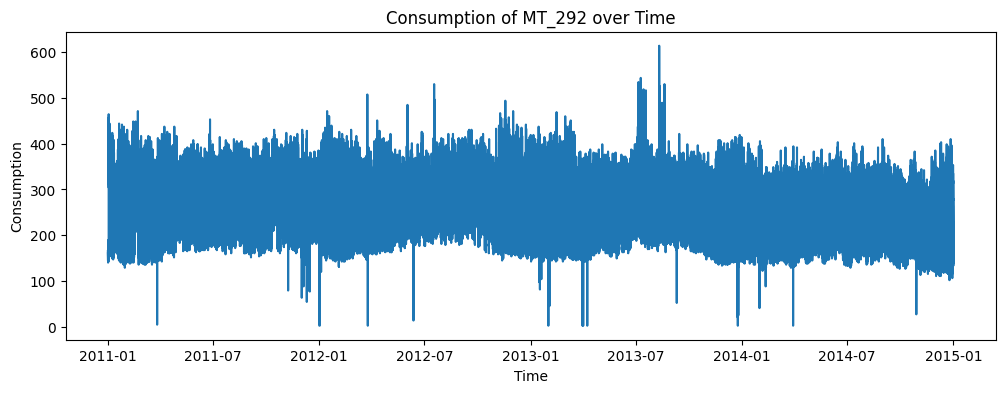

In [24]:
plt.figure(figsize=(12,4))

plt.plot(data.index.tolist(), data['MT_292'])
plt.title('Consumption of MT_292 over Time')
plt.xlabel('Time')
plt.ylabel('Consumption')
plt.show()

In [14]:
data = data['MT_292']
data.to_csv("usefull_dataset.csv", header=True)

### Reload dataset propre

In [2]:
data = pd.read_csv("usefull_dataset.csv", delimiter=',', lineterminator='\n')
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])  #convertit 1er colone en data
data.set_index('Unnamed: 0', inplace=True)  # met cette colonne comme index

print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   MT_292  140256 non-null  float64
dtypes: float64(1)
memory usage: 2.1 MB
None


Intérêt aussi de cette selection c'était de supprimer toutes les informations innutile du dataset ainsi il ne prend plus 400Mo de ram pour rien.

### Séparation en ensemble train, validation et test

On va séparer ici les dataset en 3 jeu de données différente le premier est le test c'est un jeu de donné que le modèle ne verra jamais et qui servira à tester le modèle à la fin.

Le jeu de donné train qui lui servira entrainner le modèle et le jeu de donné de validation qui lui servira à valider les changement des paramètre du modèle.

On sait que le dataset représente des date de début 2011 à fin 2014.

In [3]:
index_list = data.index.tolist()

train_limit = int(len(data) * 0.8) #prend 80% longueur data pour train et prend le début sinon prendre la fin ne fait pas de sens pour prédire ce qui avant car c'est pas ce qu'on veut
train_data = data[:train_limit]

MAE_NAIVE = mean_absolute_error(train_data['MT_292'][1:], train_data['MT_292'].shift(1).dropna())

validation_limit = int(len(data) * 0.9) #prend un peu de validation aussi
validation_data = data[train_limit:validation_limit]

test_data = data[validation_limit:] #et le reste en ensemble de test

### Métrique qu'on va utilisé

on va utiliser les métrique :
- MAE: mean average absolute error qui peut être définit comme étant : $\frac{1}{n}\sum^{n}_{i=1}|y_i-\hat{y}_i|$ rien de spécifique comme métrique assz simple à comprendre surtout moins impacté par valeur extrême. peut être aussi embêtter par le casle data
- MASE : Mean avergage scaled error. C'est une métrique qui compare prédiciton divisé par rapport au métrique de MAE d'un classifieur naïf. intérêt c'est que indépendant des problèmes de variance, comportement prédicit et d'autre condition math qui fait que pas mal
- SMAPE : symetric mean absolute percentage défini comme étant $ \text{SMAPE} = \frac{2}{n} \sum_{t=1}^n \frac{\left|F_t-A_t\right|}{|A_t|+|F_t|}$ qui permet de faire moyenne entre diff / valeur obtenur + valeur à obtenir et vois que c'est ok niveau scalling uassi

### Arima (Autoregressive integrated moving average)

Arima est un modèle qui se base sur le traitement du signal. Il utilise une partie autoregressive càd prend ancienne valeur pour prédire suite, integrated càd que prend en compte de l'intégration pour rendre le tout stationnaire. Moving average permet de faire un lien entre l'erreur résiduel et l'observation.

Cependant ce modèle n'est pas adapté à des données qui sont saisonière ça qui se répètre or en regardant les au dessus les données, on remarque que c'est le cas de nos données à nous. Je vais quand même l'essayer pour montrer à quel point c'est mauvais mais il est plus interessant d'utiliser SARIMAX pouvant prendre en compte cette saisonalité + des facteurs externe que je ne compte pas utiliser ici

In [21]:
FUTUR_WINDOW = 96  # Prédire les prochaines 96 périodes (1 jour si données toutes les 15 minutes)

def forecast_test_arima(model, test_data, best=True, limit=0):
    """
        Suppose que modèle est déjà fit sur données de train et que le test c'est juste après le train (donc peut être juste validation dans certain cas)
    """
    preds = []
    trags = []
    for i in tqdm(range(len(test_data) if best else len(test_data)// FUTUR_WINDOW)):
        if best:
            pred_step = model.forecast(steps=1)
            targ_step = [test_data[i]]
        else:
            pred_step = model.forecast(steps=FUTUR_WINDOW)
            targ_step = test_data[i*FUTUR_WINDOW:(i+1)*FUTUR_WINDOW] #prend tout ceux qu'on veut savoir
        preds.extend(pred_step)
        trags.extend(targ_step)
        # eeee = time()
        model = model.apply(targ_step, refit=False)  # donne au modèles les vrai valeur pour pas faire du long cast forecasting
        # print(f"fitting time : {time() - eeee} seconds")

    preds = np.array(preds)
    trags = np.array(trags)
    print(preds, trags)

    #calcules des métriques
    mae = mean_absolute_error(trags, preds)
    mase = mae / MAE_NAIVE
    smape = (2 * np.abs(preds - trags) / (np.abs(preds) + np.abs(trags))).mean()

    print(f"MAE: {mae} | MASE: {mase} | SMAPE: {smape}")

    cut = limit * FUTUR_WINDOW if limit > 0 else len(preds)

    trags2 = [train_data['MT_292'].iloc[-1]] + trags.tolist()

    naif_test = np.array(trags2[:-1])  # naive prediction is previous value

    plt.figure(figsize=(12,4))
    plt.plot(trags[:cut], label='Actual')
    plt.plot(preds[:cut], label='Predicted')
    plt.plot(naif_test[:cut], label='Naive Prediction', linestyle='--')
    plt.title('ARIMA Model Predictions vs Actuals for next periods forecast')
    plt.xlabel('Time Steps')
    plt.ylabel('Consumption')
    plt.legend()
    plt.show()

def long_term_metric(predictions, test_set, show_plot=True, save_name=None):
    """
        predictions: array of predicted values
        test_set: array of actual values
    """

    metric_place = [96, 672, 1440, 2688, len(predictions)]  # 1 day, 7 days, 15 days 1 month, all

    maes = []
    mases = []
    smapes = []

    for i, place in enumerate(metric_place):
        pred_cut = predictions[:place]
        test_cut = test_set[:place]
        mae = mean_absolute_error(test_cut, pred_cut)
        mase = mae / MAE_NAIVE
        smape = (2 * abs(np.array(pred_cut) - np.array(test_cut)) / (abs(np.array(pred_cut)) + abs(np.array(test_cut)) + 1e-8)).mean()
        maes.append(mae)
        mases.append(mase)
        smapes.append(smape)

    if save_name is not None:
        with open(save_name, 'w') as f:
            f.write("Horizon,MAE,MASE,SMAPE\n")
            for i, place in enumerate(metric_place):
                f.write(f"{place},{maes[i]},{mases[i]},{smapes[i]}\n")

    if not show_plot:
        return maes, mases, smapes
    fig, axs = plt.subplots(3, 1, figsize=(15, 18))

    axs[0].plot(metric_place, maes, label='MAE', marker='o', color='blue')
    axs[0].set_xticks(metric_place)
    axs[0].set_xticklabels(['1 day', '7 days', '15 days', '1 month', 'All'])
    axs[0].set_xlabel('Forecast Horizon')
    axs[0].set_ylabel('MAE')
    axs[0].set_title('MAE over Different Forecast Horizons')
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(metric_place, mases, label='MASE', marker='v', color='green')
    axs[1].set_xticks(metric_place)
    axs[1].set_xticklabels(['1 day', '7 days', '15 days', '1 month', 'All'])
    axs[1].set_xlabel('Forecast Horizon')
    axs[1].set_ylabel('MASE')
    axs[1].set_title('MASE over Different Forecast Horizons')
    axs[1].legend()
    axs[1].grid()

    axs[2].plot(metric_place, smapes, label='SMAPE', marker='s', color='red')
    axs[2].set_xticks(metric_place)
    axs[2].set_xticklabels(['1 day', '7 days', '15 days', '1 month', 'All'])
    axs[2].set_xlabel('Forecast Horizon')
    axs[2].set_ylabel('SMAPE')
    axs[2].set_title('SMAPE over Different Forecast Horizons')
    axs[2].legend()
    axs[2].grid()

    plt.tight_layout()
    plt.show()
        

In [17]:
model = ARIMA(train_data['MT_292'].tolist(), order=(2, 1, 3))  # définit arima, order c'est la paramètre (p,d,q) doit fit paramètre mais va testé avec des valeurs au pif pour voir erreur
fitted_model = model.fit() #fit au données

100%|██████████| 14026/14026 [00:32<00:00, 432.46it/s]


[319.24695823 296.72205991 285.3921387  ... 137.9451761  133.43126327
 137.9451761 ] [296.77200903 285.44018059 275.77878104 ... 133.4537246  137.96839729
 140.22573363]
MAE: 18.176193342768393 | MASE: 1.0420677092434258 | SMAPE: 0.0780501519541984


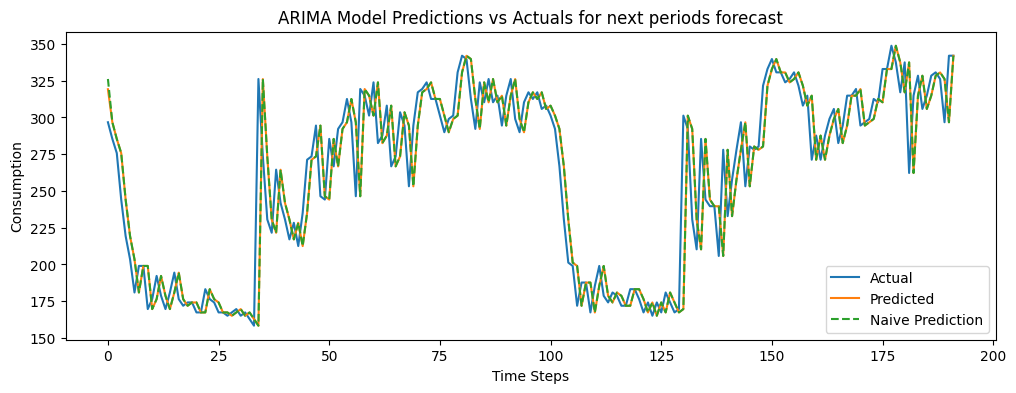

In [22]:
forecast_test_arima(fitted_model, test_data['MT_292'].tolist(), best=True, limit=2)

#### fine tune des paramètre

pour ça va applique méthode box-jenkins
soit se fait chier à la faire à la main soit utilise la fonction autoarima qui va faire la méthode + des méthode plus récent avec mielleur système que grid search pour trouver des bon paramètre. Sert juste à se simplifier la vie et pas tout implémenter par nous même

In [ ]:
model = auto_arima(
    train_data['MT_292'],
    seasonal=False,
    stepwise=True,
    information_criterion='aic',
    max_p=5,
    max_q=5,
    d=None,        # auto-detect
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1048682.975, Time=18.65 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1056098.124, Time=1.34 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1049704.421, Time=1.69 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1048904.256, Time=5.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1056096.125, Time=0.56 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1048801.392, Time=33.78 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1048797.380, Time=25.04 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1048605.974, Time=35.02 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1048616.997, Time=29.43 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=1048611.762, Time=29.00 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=1048606.702, Time=31.42 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1048604.721, Time=27.82 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1048625.030, Time=27.43 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=1048609.6

Cette anlyse nous donne que les meilleur paramètre sont p=2, d=1, q=3

Cela veut donc dire qu'on va prendre que 2 terme de passé, intégré que d'un degré et prend 3 terme de bruit
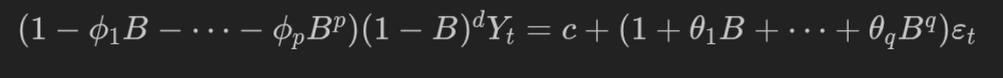

Si on utilise ça pour recalculer les métriques on obtient que

MAE: 74.03265575529778
MASE: 4.244400273329186
SMAPE: 28.612446975550704


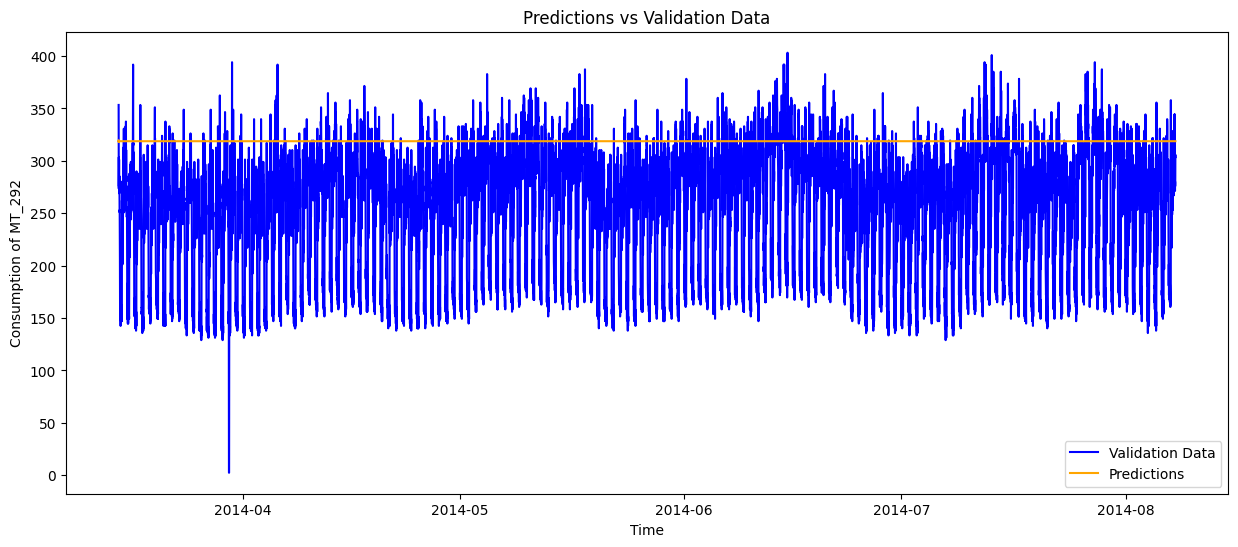

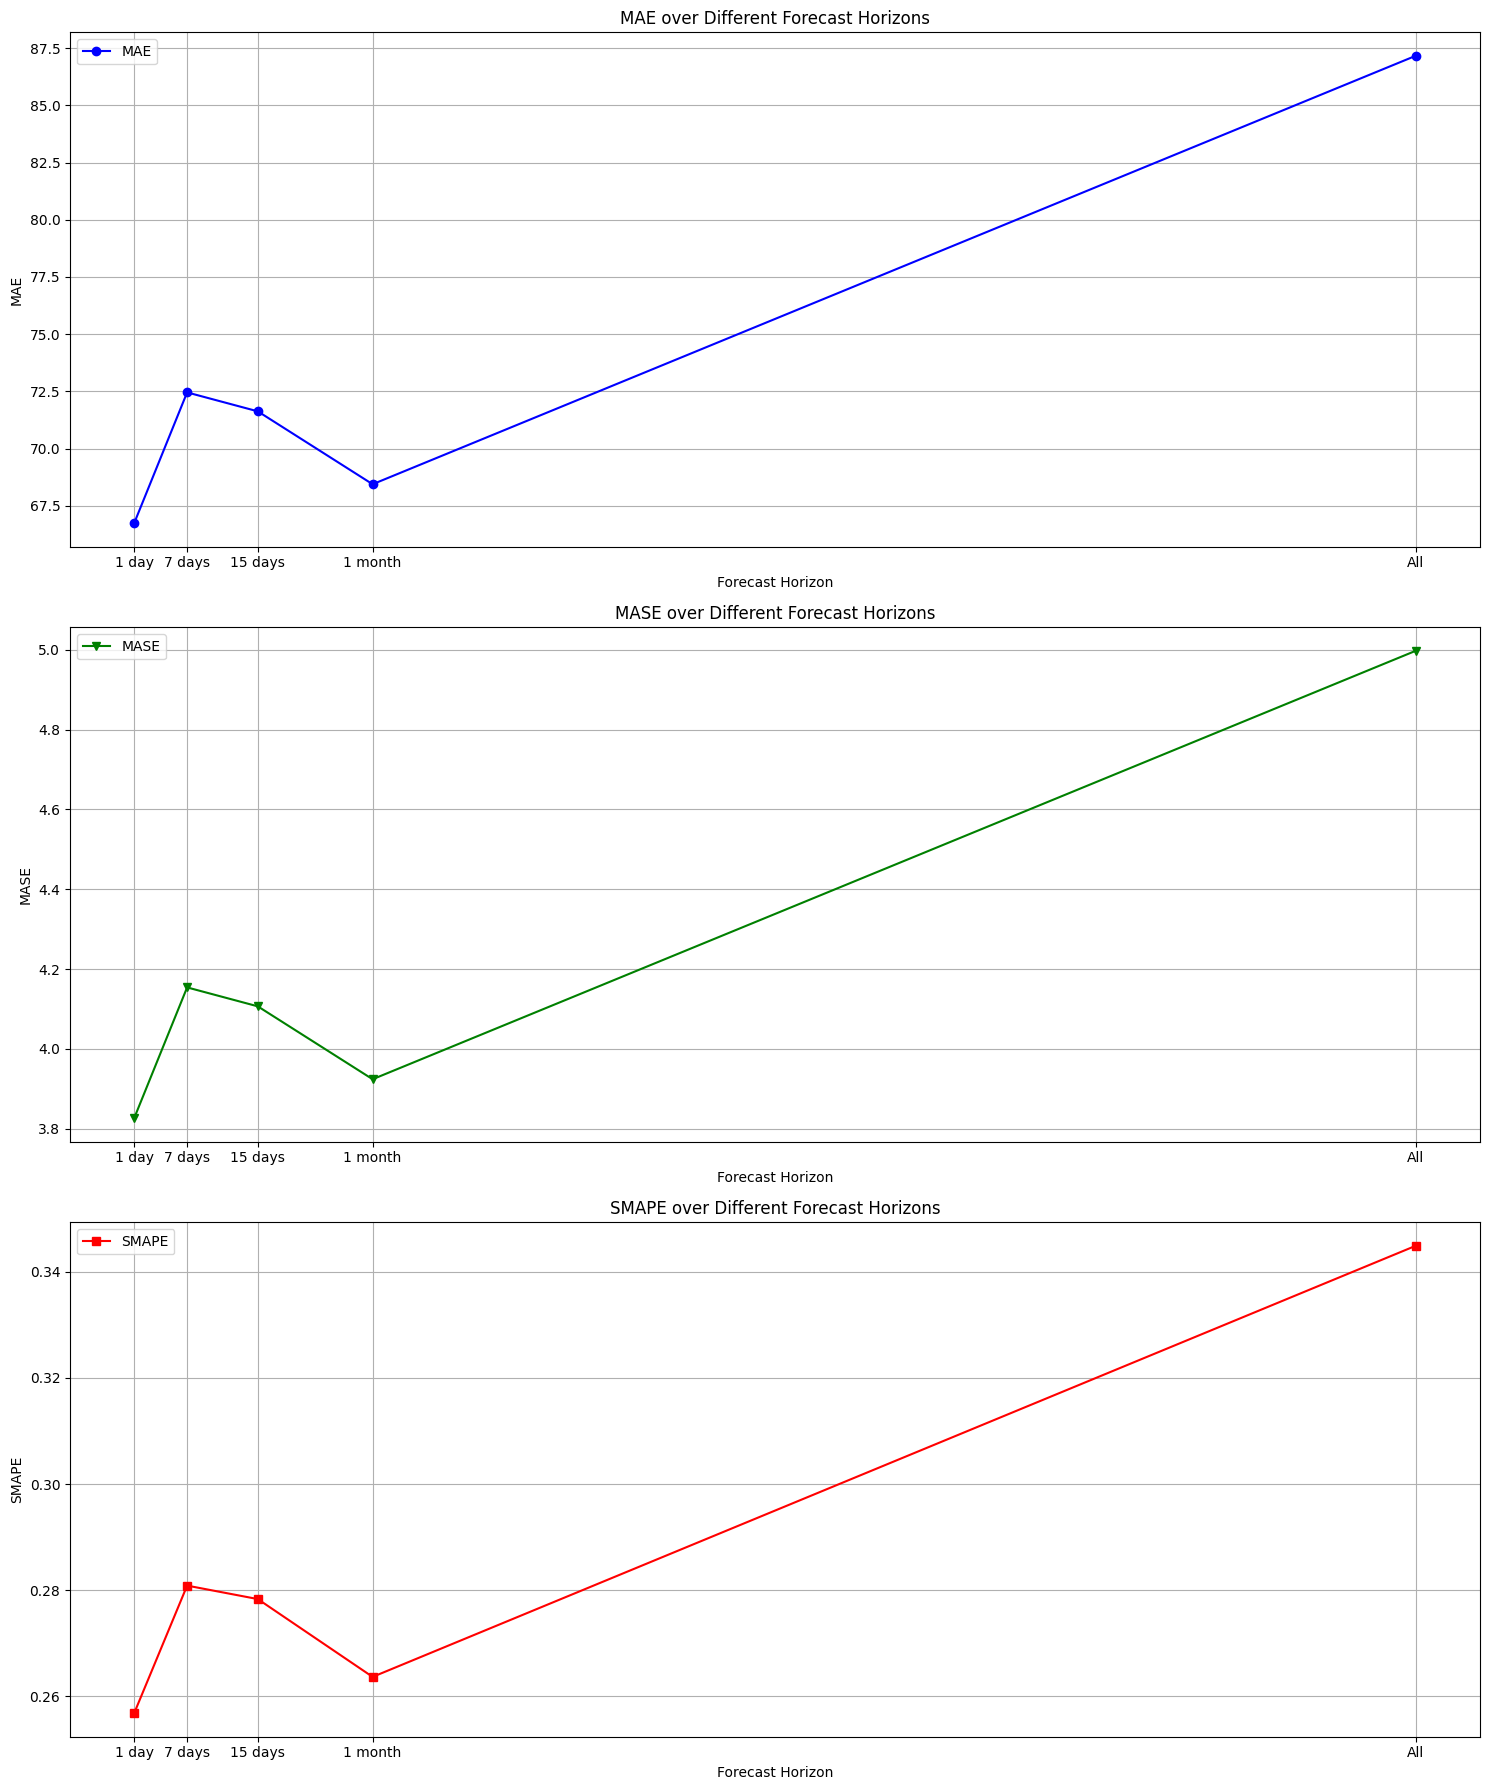

In [20]:
model = ARIMA(train_data['MT_292'].tolist(), order=(2, 1, 3))  # définit arima, order c'est la paramètre (p,d,q) doit fit paramètre mais va testé avec des valeurs au pif pour voir erreur
fitted_model = model.fit() #fit au données

#créer prediction avec les données de validation
predictions = fitted_model.forecast(steps=len(validation_data))

# calcule la mae
mae = mean_absolute_error(validation_data['MT_292'], predictions) #calcule erreur absolue moyenne entre données validation et prédictions

# calcule MASE
naive_forecast = train_data.shift(1).dropna() #prediction de naive forecast qui est juste un décalage
mase = mae / mean_absolute_error(train_data['MT_292'][1:], naive_forecast) #calcule la mae, je sais que peut faire plus opti avec pandas mais osef


# calcule SMAPE
actual = validation_data['MT_292'].values
smape = 100 * (2 * abs(predictions - actual) / (abs(predictions) + abs(actual))).mean() #pareil pour smape

print(f"MAE: {mae}")
print(f"MASE: {mase}")
print(f"SMAPE: {smape}")

plt.figure(figsize=(15, 6))
plt.plot(validation_data.index, validation_data['MT_292'], label='Validation Data', color='blue')
plt.plot(validation_data.index, predictions, label='Predictions', color='orange')
plt.title('Predictions vs Validation Data')
plt.xlabel('Time')
plt.ylabel('Consumption of MT_292')
plt.legend()
plt.show()


long_term_metric(predictions, test_data['MT_292'].values, save_name="arima_long_term_metrics.csv")

#### Remraque

A voir, faudrait utilise SARIMA car arima simple n'a que 1 dépendance dans le temps et si doit mettre un grand chiffre devient compliqué à calculer les poids alors que sarima permet d'avoir 2 moyenne 1 court et long terme de ce que j'ai compris

car les métrique ici surtout SMAPE et MASE sont vraiment pas bonne et disent que ce modèle ne vaut rien.

Ces résultats sont attendu étant donné ARIMA n'aime pas les pattern et la saisonalité. Pour ça il faut utilise SARIMA

résultat aussi un ligne comme regarde que 30 minute avant donc oui normal qu'il arrive pas à trouver bonne prédiction.


### SARIMA

In [129]:
PAST_WINDOW = 7 * 96  # Utiliser les données des 7 derniers jours pour prédire
sarima_model = SARIMAX(
    train_data['MT_292'][-7*96:],  # Using the last 60 days of training data for fitting
    order=(2, 1, 3),  # (p, d, q)
    seasonal_order=(1, 1, 1, 96),  # (P, D, Q, m) where m is the seasonal period
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fitted = sarima_model.fit(disp=False)


/home/cyril/anaconda3/envs/adl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/home/cyril/anaconda3/envs/adl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/home/cyril/anaconda3/envs/adl/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


100%|██████████| 14026/14026 [03:18<00:00, 70.66it/s] 


[314.97658846 371.47208646 357.28793894 ... 172.69623431 167.04517952
 172.69623431] [296.77200903 285.44018059 275.77878104 ... 133.4537246  137.96839729
 140.22573363]
MAE: 61.351231167298295 | MASE: 3.5173556814747764 | SMAPE: 0.23259407669103116


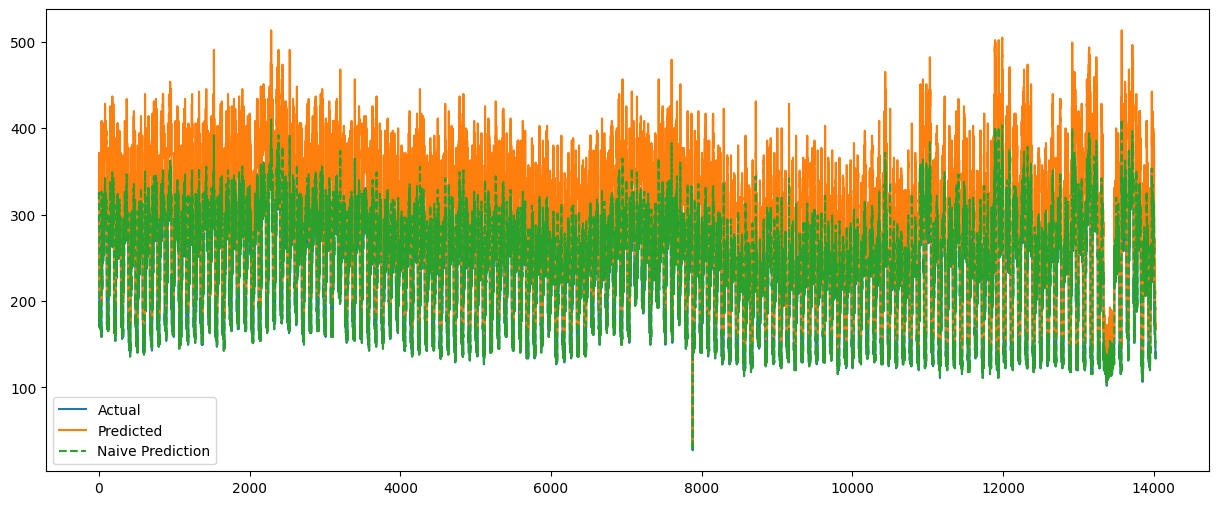

In [174]:
forecast_test_arima(sarima_fitted, test_data['MT_292'].tolist(), best=True, limit=0)

#### Remarque

La complexité des méthode arima et dérivé est assez spécial car elle est linéaire en la longueur de la série + multiplié par k² qui dépend de combien de temps on veut que la série est capable d'aller en arrière si on veut quelque chose de ok comme retourner 1 jour en arrière il faut 96. mais 96² . 120 000 ça fait beaucoup et très peu calculable

en plus arima et sarima se veut pour prédire à court therme.


### Random forest

peut être interessant car permet de faire une sliding windows un peu comme arima mais peut facilement l'étendre à une plus grande fenêtre ce qui est un problème dans notre cas à nous ici. Mais ne va pas forcement comprendre tout à lon gterme comme SARIMA est censé faire mais que je n'arrive pas à train.

pour faire ça doit extraire des feature nous même en faisant des lag car après on fera de la regression donc fait des difference sur peur de temps puis sur de plus en plus long

In [5]:
FUTUR_WINDOW = 96  # Prédire les prochaines 96 périodes (1 jour si données toutes les 15 minutes)
PAST_WINDOW = 96*4  # Utiliser les 96 périodes précédentes comme caractéristiques

def create_lag_features(df, target_col):
    df = df.copy()

    lags = np.arange(1, PAST_WINDOW+1)  # Crée des lags de 1 à 96 (1 jour complet si données toutes les 15 minutes) 673 pour avoir un jour derrière c'est vraiment lent à train
    for lag in lags:
        df[f'lag_{lag}'] = df[target_col].shift(lag)

    return df

def create_supervised_rf(df, target_col, past_window=PAST_WINDOW, future_window=FUTUR_WINDOW):
    df = df.copy()

    # cxcréer les feature lag pour avoir pas window
    for lag in range(1, past_window + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)

    # ---- Future targets (outputs) ----
    for step in range(1, future_window + 1):
        df[f'y_{step}'] = df[target_col].shift(-step)

    df = df.dropna()

    X = df[[f'lag_{i}' for i in range(1, past_window + 1)]].values
    y = df[[f'y_{i}' for i in range(1, future_window + 1)]].values

    return X, y

if FUTUR_WINDOW == 1:
    data_rf = create_lag_features(data, 'MT_292')
    # data_rf = add_time_features(data_rf) #test sans ajout des dates
    data_rf = data_rf.dropna()

    # resplit comme beaucoup modifié
    n = len(data_rf)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    train = data_rf.iloc[:train_end]
    val = data_rf.iloc[train_end:val_end]
    test = data_rf.iloc[val_end:]

    X_train, y_train = train.drop(columns=['MT_292']), train['MT_292']
    X_val, y_val = val.drop(columns=['MT_292']), val['MT_292']
    X_test, y_test = test.drop(columns=['MT_292']), test['MT_292']
else:
    X_total, y_total = create_supervised_rf(data, 'MT_292', past_window=PAST_WINDOW, future_window=FUTUR_WINDOW)

    # resplit comme beaucoup modifié
    n = len(X_total)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    X_train, y_train = X_total[:train_end], y_total[:train_end]
    X_val, y_val = X_total[train_end:val_end], y_total[train_end:val_end]
    X_test, y_test = X_total[val_end:], y_total[val_end:]

/tmp/ipykernel_354075/2260223287.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_{lag}'] = df[target_col].shift(lag)
/tmp/ipykernel_354075/2260223287.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_{lag}'] = df[target_col].shift(lag)
/tmp/ipykernel_354075/2260223287.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fra

In [6]:
def test_model(model, x_to_use, y_to_use, best=True, limit=0):
    """
        suppponse que le modèle arrive train
    """

    mae = 0
    smape = 0

    #commence par prédire
    predictions = model.predict(x_to_use)
    pred = predictions[:,0] if best else predictions #en gros si mets best revient à prendre les premier prédit même si modèle peut faire pour plusieurs d'un coup
    target = y_to_use[:,0] if best else y_to_use #pareil pour les y

    pred_show = pred.copy()
    target_show = target.copy()
    if not best:
        pred_show = np.zeros(len(pred))
        target_show = np.zeros(len(pred))
        for i in range(len(pred) // FUTUR_WINDOW):
            pred_show[i*FUTUR_WINDOW:(i+1)*FUTUR_WINDOW] = predictions[i*FUTUR_WINDOW]
            target_show[i*FUTUR_WINDOW:(i+1)*FUTUR_WINDOW] = y_to_use[i*FUTUR_WINDOW]


    # calcule mae
    mae = mean_absolute_error(target_show, pred_show)

    # Calculate MASE
    mase = mae / MAE_NAIVE #caculé avant les mae naive sur le train donc ne fait que le divisé ne comprend rien à cette métrique car compare sur le train et la sur le test

    # Calculate SMAPE
    smape = (2 * abs(pred_show - target_show) / (abs(pred_show) + abs(target_show) + 1e-8)).mean() # si applique définition simple ajoute epsilon pour stabilité numérique

    print(f"MAE: {mae}")
    print(f"MASE: {mase}")
    print(f"SMAPE: {smape}")


    cut = len(target_show) if limit == 0 else limit*FUTUR_WINDOW

    plt.figure(figsize=(15, 6))
    plt.plot(target_show[:cut], label='Actual Data', color='blue')
    plt.plot(pred_show[:cut], label='Model Predictions', color='orange')
    if not best:
        plt.xticks(ticks=np.arange(0, len(target_show[:cut]), FUTUR_WINDOW), labels=np.arange(0, len(target_show[:cut]) // FUTUR_WINDOW))
    plt.title('Model Predictions vs Actual Data')
    plt.xlabel('Time')
    plt.ylabel('Consumption of MT_292')
    plt.legend()
    plt.show()

def long_term_forecast(model, test_set):
    """
        last_known_data: array of shape (PAST_WINDOW,)
        steps: number of future steps to predict
    """
    history = test_set[:PAST_WINDOW].tolist()  # Prend les dernières données connues comme point de départ
    history = history[::-1] #doit flip car prend (dernier, avant dernier, ......) car me suis foiré dane ltra
    predictions = []

    # print(history)

    for _ in range((len(test_set) // FUTUR_WINDOW )-1):
        # print(history[-PAST_WINDOW:])
        input_data = np.array(history[:PAST_WINDOW]).reshape(1, -1)
        # print(input_data)
        next_pred = model.predict(input_data)[0] #prédit +1, +2, +3 mais dans historique doit avoir -1, -2 ,-3 donc faut le flip et push devant l'historique
        predictions.extend(next_pred)
        history = next_pred[::-1].tolist() + history[:-len(next_pred)]  # Ajoute la prédiction au début de l'historique et retire les plus anciennes valeurs


    plt.figure(figsize=(15, 6))
    plt.plot(test_set[PAST_WINDOW:][:FUTUR_WINDOW*4], label='Actual Data', color='blue')
    plt.plot(predictions[:FUTUR_WINDOW*4], label='Long-term Forecast', color='orange')
    plt.title('Long-term Forecast vs Actual Data')
    plt.xlabel('Time')
    plt.ylabel('Consumption of MT_292')
    plt.legend()
    plt.show()

    return predictions


        


In [25]:
#train 
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


building tree 1 of 50
building tree 2 of 50
building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  2.2min


building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50
building tree 40 of 50
building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50


[Parallel(n_jobs=-1)]: Done  45 out of  50 | elapsed:  6.7min remaining:   44.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  7.1min finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  45 out of  50 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished


MAE: 18.801278547628947
MASE: 1.0779047569259186
SMAPE: 0.07738304102932517


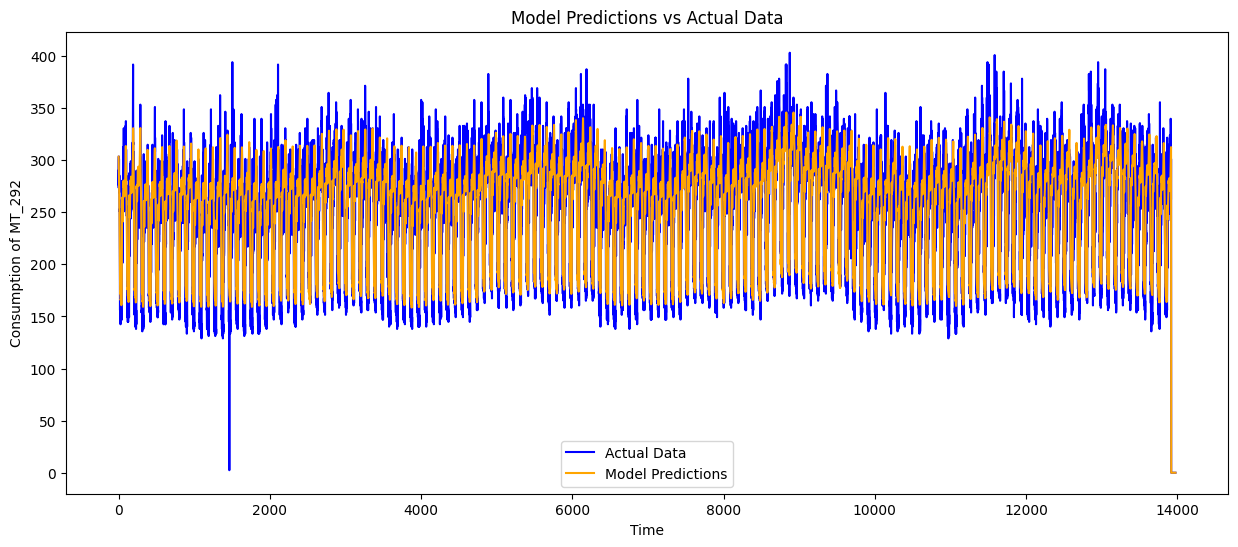

In [62]:
test_model(rf, X_val, y_val, best=False, limit=0)

On peut effectueur un Grid search afin de trouver des meilleurs paramètre parmis un ensemble défini. Comme je veux utiliser une des métrique défini avant, il serait compliqué d'utiliser les fonction existante mais comme randomforest est déjà multithread, juste un for est suffisant pour avoir une utilisation optimale du processeur.

In [ ]:
estimator_list = [5, 10, 20, 30,]
max_depth_list = [10, 15,  20]
min_samples_leaf_list = [1, 5, 10]


hyperparameter_combinations = list(product(estimator_list, max_depth_list, min_samples_leaf_list))

best_mae = float('inf')
best_hyperparameters = None

for n_estimators, max_depth, min_samples_leaf in tqdm(hyperparameter_combinations):
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        criterion='absolute_error',
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    val_predictions = rf.predict(X_val)
    mae = mean_absolute_error(y_val, val_predictions)

    if mae < best_mae:
        best_mae = mae
        best_hyperparameters = (n_estimators, max_depth, min_samples_leaf)
        print(f"New best MAE: {best_mae} with hyperparameters: {best_hyperparameters}")

  1%|          | 1/120 [00:01<03:39,  1.85s/it]

New best MAE: 13.754126865853506 with hyperparameters: (50, 10, 1)


  2%|▏         | 2/120 [00:03<03:38,  1.85s/it]

New best MAE: 13.687003313379353 with hyperparameters: (50, 10, 5)


  4%|▍         | 5/120 [00:11<04:59,  2.60s/it]

New best MAE: 13.327370038225286 with hyperparameters: (50, 20, 1)


  5%|▌         | 6/120 [00:14<05:24,  2.84s/it]

New best MAE: 13.239772959157829 with hyperparameters: (50, 20, 5)


 22%|██▏       | 26/120 [01:30<08:07,  5.19s/it]

New best MAE: 13.22426990880017 with hyperparameters: (100, 20, 5)


 38%|███▊      | 46/120 [03:51<11:56,  9.69s/it]

New best MAE: 13.196097528920314 with hyperparameters: (200, 20, 5)


 55%|█████▌    | 66/120 [07:57<13:14, 14.72s/it]

New best MAE: 13.187482921637427 with hyperparameters: (300, 20, 5)


 58%|█████▊    | 70/120 [09:09<14:52, 17.85s/it]

New best MAE: 13.1869411304151 with hyperparameters: (300, 30, 5)


 72%|███████▏  | 86/120 [13:49<11:11, 19.74s/it]

New best MAE: 13.181216536665117 with hyperparameters: (400, 20, 5)


 75%|███████▌  | 90/120 [15:26<11:57, 23.91s/it]

New best MAE: 13.180405692417981 with hyperparameters: (400, 30, 5)


 88%|████████▊ | 106/120 [21:30<05:46, 24.78s/it]

New best MAE: 13.176011644415272 with hyperparameters: (500, 20, 5)


 92%|█████████▏| 110/120 [23:31<04:58, 29.82s/it]

New best MAE: 13.174686934546923 with hyperparameters: (500, 30, 5)


100%|██████████| 120/120 [28:25<00:00, 14.21s/it]


In [7]:
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

print(X_train_full.shape, y_train_full.shape)

#train 
rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_full, y_train_full)


(125798, 384) (125798, 96)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

MAE: 22.960458638550804
MASE: 1.3163566256942596
SMAPE: 0.1023408752689858


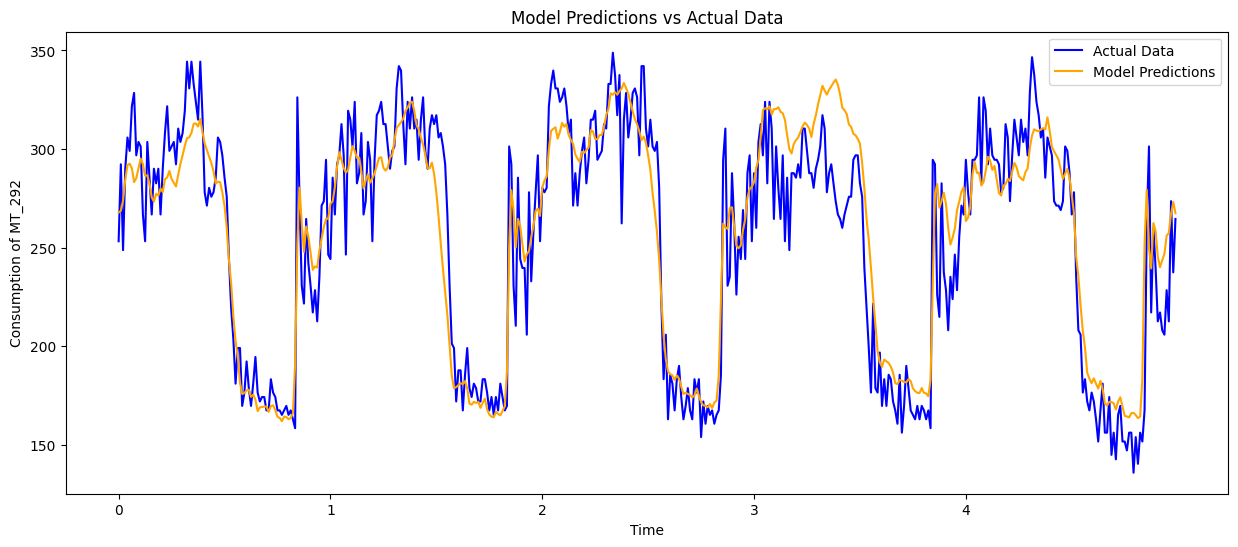

In [12]:
test_model(rf, X_test, y_test, best=False, limit=5)

### longterm forecasting

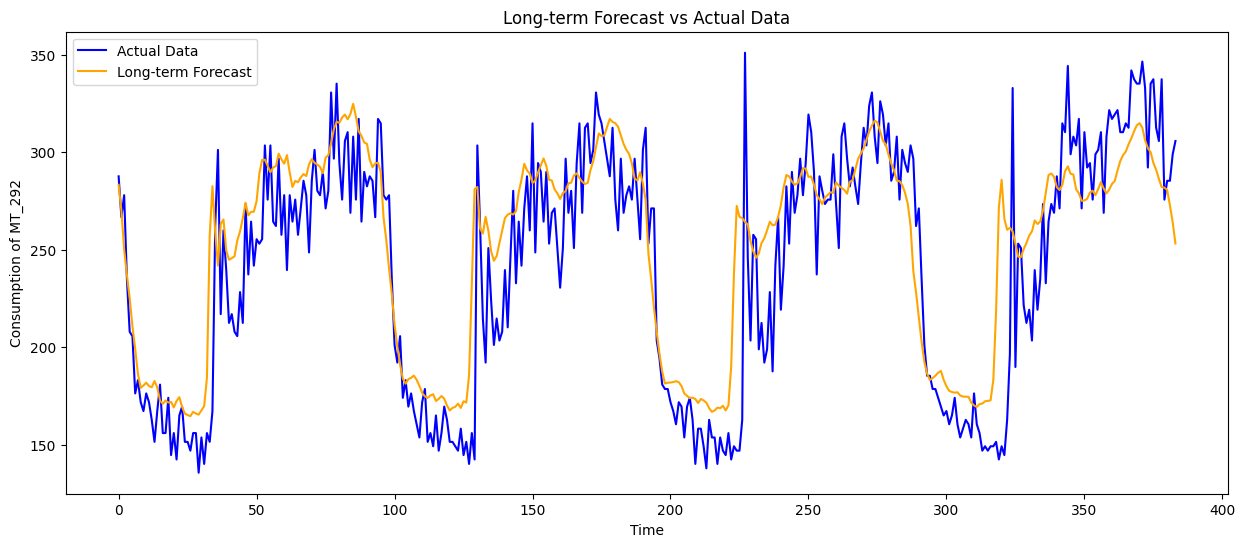

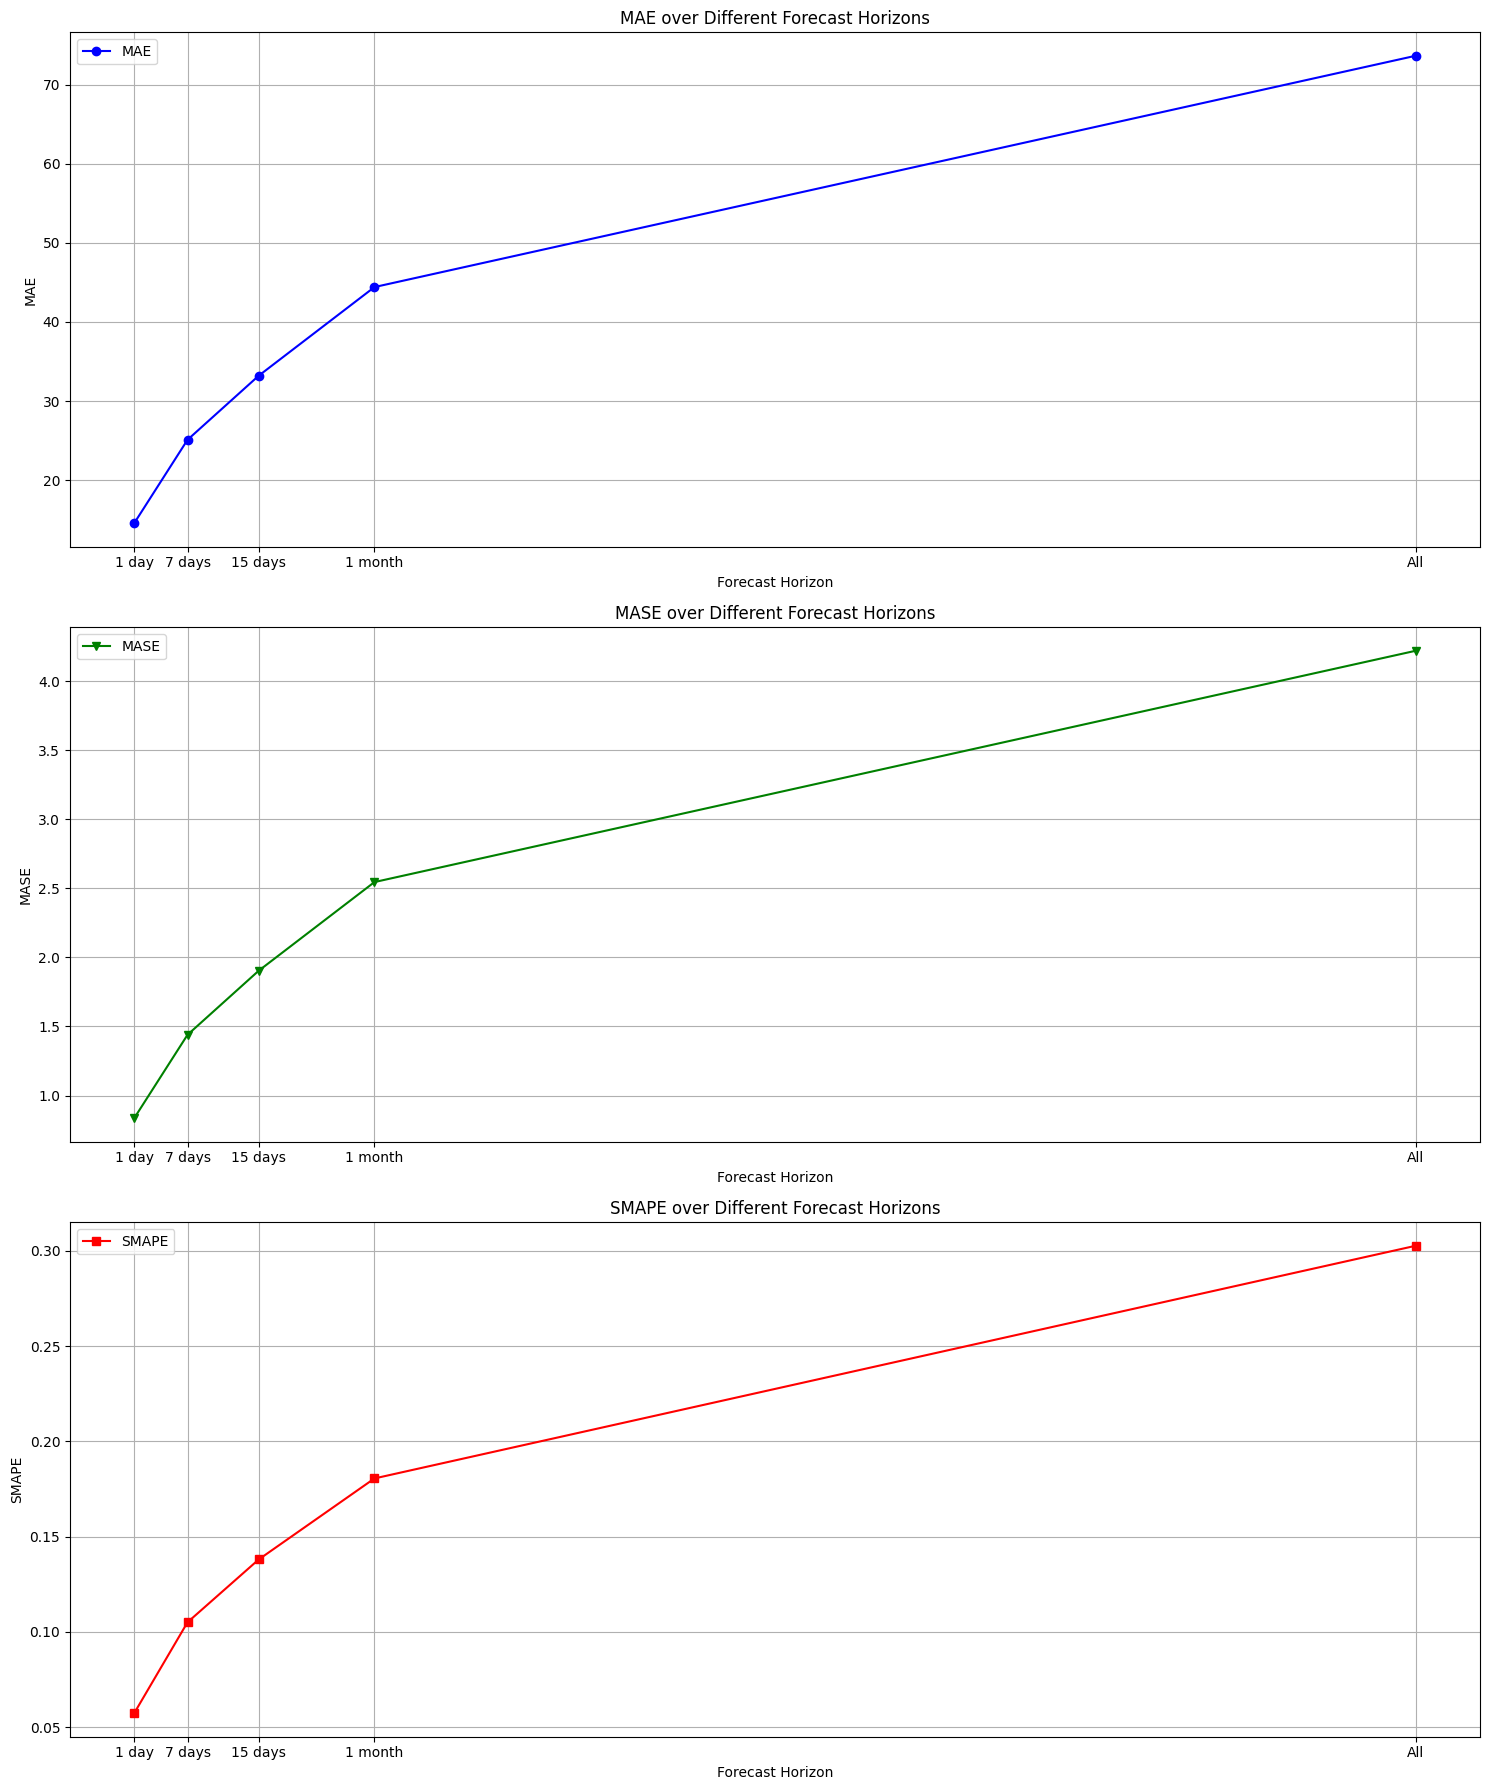

In [15]:
preds = long_term_forecast(rf, test_data['MT_292'].values)

long_term_metric(preds, test_data['MT_292'].values, save_name="rf_long_term_metrics.csv")

### Résultat

En cherchant par un grid serach simple en optimisant la MAE, on obtient que les meilleurs paramètres sont:
- n-estimator = 30
- max-depth = 20
- min_sample_leaf = 5

Devrait être encore plus lent mais alors entrainement devient très lent.

Cela donne des métriques qui commencent à être interessant et meilleur qu'un simle naïve forecasting.
Le graphique aussi commence à donner des résultats qui suivent bien et qui est en tout cas bien meilleur que le 1er.